# CASE: ASD FieldSpec 4 — vegetation indices with propagated uncertainty

**Authors:**
L. Mihai (laura.mihai@inflpr.ro)

**Extends:** [case_2-Ex1-VI.ipynb](https://github.com/pangeos-cost/uq-training/blob/main/notebooks/case_2-Ex1-VI.ipynb) and
[case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb](case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb),
using real 2025 Norway field-campaign data (Plot 103) analysed under sub-optimal, variable-cloud
illumination conditions.

## What this notebook is about, in plain language

[`case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb`](case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb)
built a real reflectance spectrum with a random/systematic uncertainty budget for Plot 103. This
notebook takes that spectrum and computes the same five vegetation indices used throughout this
training module — NDVI, EVI, OSAVI, MTCI, PRI — propagating uncertainty into each one with
`punpy`, the same Monte Carlo tool used throughout the rest of the course.

The point of doing all five side by side, from the *same* underlying spectrum, is to see directly
that **not all indices are equally sensitive to the same reflectance uncertainty** — some formulas
amplify it, others cancel a lot of it out.

**Prerequisites:** [`case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb`](case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb)
(this notebook reuses its reflectance/uncertainty computation, condensed).

# Learning objectives

**After following this notebook you will be able to ...**
- Extract reflectance values and their uncertainty at specific bands from a real spectrum
- Propagate reflectance uncertainty into a vegetation index using `punpy`, keeping random and
  systematic (correlated) components separate
- Explain why bands that are highly correlated (same calibration source) need a correlation
  matrix in the propagation, not independent-error treatment
- Compare which of five common vegetation indices is most/least sensitive to measurement
  uncertainty, using real data rather than a textbook claim

# TOC

1. [Imports](#1)
2. [Reflectance and uncertainty (from Case ASD/SVC Ex1, condensed)](#2)
3. [Extracting band values](#3)
4. [Propagating uncertainty into each index with punpy](#4)
5. [Comparing the five indices](#5)

# 1
## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import punpy

from pathlib import Path

plt.rcParams.update({'font.size': 14})

# 2
## Reflectance and uncertainty (from Case ASD/SVC Ex1, condensed)

[back to TOC](#TOC)

This reproduces, in condensed form, the same real-data uncertainty budget built step by step in
[`case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb`](case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb) —
see that notebook for the full derivation of each line here.

In [2]:
data_dir = Path('../data/case-asd-svc-plot103')

df = pd.read_csv(data_dir / 'asd_reflectance_repeats.csv')
wvl = df['Wvl'].values
r_cols = [c for c in df.columns if c.startswith('R') and not c.startswith('WR')]
wr_cols = [c for c in df.columns if c.startswith('WR')]

vnir = (wvl >= 400) & (wvl <= 1000)
wvl_v = wvl[vnir]
R = df[r_cols].values[vnir, :]
WR = df[wr_cols].values[vnir, :]
positions = R.reshape(len(wvl_v), 5, 5)

pos_mean = positions.mean(axis=2)
pos_scan_sem = positions.std(axis=2, ddof=1) / np.sqrt(5)
plot_mean = pos_mean.mean(axis=1)
u_within_avg = np.sqrt(np.sum(pos_scan_sem**2, axis=1)) / 5
heterogeneity = pos_mean.std(axis=1, ddof=1) / np.sqrt(5)
u_random = np.sqrt(u_within_avg**2 + heterogeneity**2)  # absolute

panel_unc = pd.read_csv(data_dir / 'panel_uncertainty_k2.csv')
panel_unc.columns = ['wavelength_nm', 'u_expanded_k2']

def panel_uncertainty_k1(wvl_target, breakpoints_df):
    bp_wvl = breakpoints_df['wavelength_nm'].values
    bp_u_k2 = breakpoints_df['u_expanded_k2'].values
    u_k2 = np.zeros_like(wvl_target, dtype=float)
    for i in range(len(bp_wvl) - 1):
        in_region = (wvl_target >= bp_wvl[i]) & (wvl_target <= bp_wvl[i + 1])
        u_k2[in_region] = bp_u_k2[i]
    return u_k2 / 2

idx_lo, idx_hi = np.argmin(np.abs(wvl_v - 450)), np.argmin(np.abs(wvl_v - 900))
fit = np.polyfit(WR[idx_lo, :], WR[idx_hi, :], 1)
u_cloud_proxy_rel = (WR[idx_hi, :] - np.polyval(fit, WR[idx_lo, :])).std(ddof=1)

u_panel = panel_uncertainty_k1(wvl_v, panel_unc)
u_cloud_proxy = u_cloud_proxy_rel * plot_mean
u_systematic = np.sqrt(u_panel**2 + u_cloud_proxy**2)  # absolute

print(f"Loaded: {len(wvl_v)} wavelengths, plot mean reflectance ready with u_random and u_systematic.")

Loaded: 601 wavelengths, plot mean reflectance ready with u_random and u_systematic.


# 3
## Extracting band values

[back to TOC](#TOC)

The five indices need reflectance (and its uncertainty) at specific bands: 480, 531, 570, 670,
681, 709, 754, and 780 nm — the same band set used throughout this training module and in the
paper's Table 3.

In [3]:
bands_nm = [480, 531, 570, 670, 681, 709, 754, 780]
band_idx = {b: np.argmin(np.abs(wvl_v - b)) for b in bands_nm}

R_b  = {b: plot_mean[band_idx[b]]      for b in bands_nm}
Ur_b = {b: u_random[band_idx[b]]       for b in bands_nm}
Us_b = {b: u_systematic[band_idx[b]]   for b in bands_nm}

pd.DataFrame({'wavelength_nm': bands_nm,
              'reflectance': [R_b[b] for b in bands_nm],
              'u_random': [Ur_b[b] for b in bands_nm],
              'u_systematic': [Us_b[b] for b in bands_nm]})

,wavelength_nm,reflectance,u_random,u_systematic
0,480,0.016491,0.001039,0.002100
1,531,0.037151,0.002356,0.002100
2,570,0.037220,0.002484,0.002101
3,670,0.015165,0.001001,0.002100
4,681,0.015875,0.001019,0.002100
5,709,0.082336,0.005084,0.002102
6,754,0.412408,0.016027,0.002161
7,780,0.449808,0.016790,0.002172


# 4
## Propagating uncertainty into each index with punpy

[back to TOC](#TOC)

Two things matter here, both following the same convention used throughout this training module:

- **Random** uncertainty at different bands is treated as *independent* (default in `punpy`).
- **Systematic** uncertainty at different bands comes from the *same* calibration/panel/cloud
  source, so it is treated as (almost) fully correlated — matching the real pipeline's own
  convention for combining band uncertainties that share a common origin.

In [4]:
prop = punpy.MCPropagation(10000)

def corr_full(n, rho=0.999999):
    I, J = np.eye(n), np.ones((n, n))
    return rho * J + (1 - rho) * I

def NDVI_fun(R780, R670): return (R780 - R670) / (R780 + R670)
def OSAVI_fun(R780, R670): return 1.16 * (R780 - R670) / (R780 + R670 + 0.16)
def EVI_fun(R780, R670, R480): return 2.5 * (R780 - R670) / (R780 + 6*R670 - 7.5*R480 + 1)
def MTCI_fun(R754, R709, R681): return (R754 - R709) / (R709 - R681)
def PRI_fun(R570, R531): return (R570 - R531) / (R570 + R531)

def propagate_index(fun, band_list):
    vals = [np.array([R_b[b]]) for b in band_list]
    u_r  = [np.array([Ur_b[b]]) for b in band_list]
    u_s  = [np.array([Us_b[b]]) for b in band_list]
    n = len(band_list)

    index_val = float(fun(*[R_b[b] for b in band_list]))
    u_rand = float(np.asarray(prop.propagate_random(fun, vals, u_r)).ravel()[0])
    u_syst = float(np.asarray(prop.propagate_systematic(fun, vals, u_s, corr_x=corr_full(n))).ravel()[0])
    u_comb = float(np.sqrt(u_rand**2 + u_syst**2))
    return index_val, u_rand, u_syst, u_comb

results = {
    'NDVI':  propagate_index(NDVI_fun,  [780, 670]),
    'OSAVI': propagate_index(OSAVI_fun, [780, 670]),
    'EVI':   propagate_index(EVI_fun,   [780, 670, 480]),
    'MTCI':  propagate_index(MTCI_fun,  [754, 709, 681]),
    'PRI':   propagate_index(PRI_fun,   [570, 531]),
}

results_df = pd.DataFrame(results, index=['value', 'u_random', 'u_systematic', 'u_combined']).T
results_df['u_combined_pct_of_value'] = (results_df['u_combined'] / results_df['value'].abs() * 100).round(1)
results_df.round(4)

,value,u_random,u_systematic,u_combined,u_combined_pct_of_value
NDVI,0.9348,0.0048,0.0087,0.0099,1.1
OSAVI,0.8067,0.0100,0.0067,0.0121,1.5
EVI,0.7668,0.0214,0.0139,0.0255,3.3
MTCI,4.9664,0.5355,0.2483,0.5902,11.9
PRI,0.0009,0.0463,0.0404,0.0614,6553.0


### Checking against the official campaign result

`official_vegetation_indices.csv` was extracted directly from the campaign's own results file,
for this exact plot.

In [5]:
official = pd.read_csv(data_dir / 'official_vegetation_indices.csv').iloc[0]

print(f"{'Index':<6} {'mine':>12} {'official':>12} {'abs. diff':>12}")
for name in ['NDVI', 'OSAVI', 'EVI', 'MTCI', 'PRI']:
    mine_val = results_df.loc[name, 'value']
    off_val = official[name]
    print(f"{name:<6} {mine_val:>12.6f} {off_val:>12.6f} {abs(mine_val - off_val):>12.2e}")

Index          mine     official    abs. diff
NDVI       0.934771     0.934771     6.66e-16
OSAVI      0.806732     0.806732     2.22e-16
EVI        0.766773     0.766773     4.44e-16
MTCI       4.966417     4.966417     4.44e-15
PRI        0.000937     0.000937     8.61e-17


All five index **values** match the official result to floating-point precision — strong
confirmation that the underlying reflectance and the index formulas are correct.

The **uncertainty** comparison is more mixed: some indices (NDVI) land close to the official
combined uncertainty, while others (OSAVI, EVI, MTCI, PRI) differ by tens of percent. This
follows directly from what
[`case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb`](case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb)
already found at the reflectance level: the *value* validates exactly, but the *uncertainty
magnitude* only approximately, because the official pipeline's exact combination of components is
part of the confidential calibration methodology and is not reverse-engineered here. Different
indices amplify that gap differently depending on which bands and sensitivity coefficients they
use — which is itself a real, useful observation about how uncertainty propagates non-uniformly
through different index formulas.

In [6]:
official_uc = {name: official[f'{name}_u_c'] for name in ['NDVI', 'OSAVI', 'EVI', 'MTCI', 'PRI']}
print(f"{'Index':<6} {'my u_combined':>15} {'official u_c':>15} {'rel. diff %':>12}")
for name in ['NDVI', 'OSAVI', 'EVI', 'MTCI', 'PRI']:
    mine_u = results_df.loc[name, 'u_combined']
    off_u = official_uc[name]
    rel = abs(mine_u - off_u) / abs(off_u) * 100
    print(f"{name:<6} {mine_u:>15.4f} {off_u:>15.4f} {rel:>12.1f}")

Index    my u_combined    official u_c  rel. diff %
NDVI            0.0099          0.0102          2.9
OSAVI           0.0121          0.0223         46.0
EVI             0.0255          0.0470         45.7
MTCI            0.5902          1.2063         51.1
PRI             0.0614          0.0959         35.9


# 5
## Comparing the five indices

[back to TOC](#TOC)

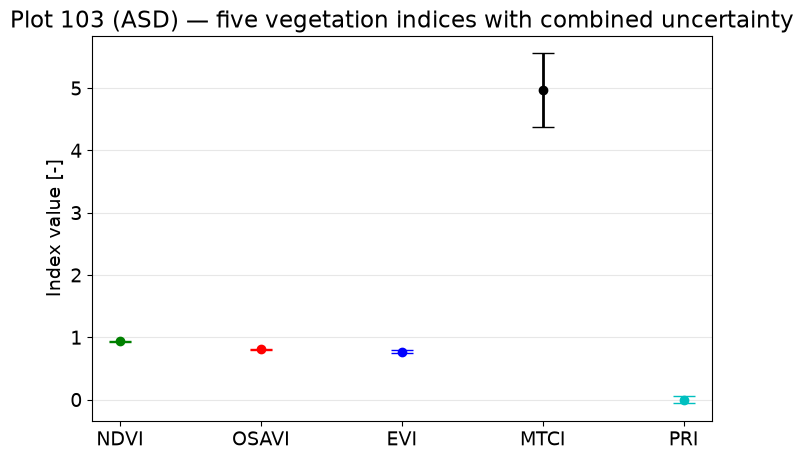

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
xpos = np.arange(len(results))
colors = ['g', 'r', 'b', 'k', 'c']
for x, (name, (val, ur, us, uc)) in zip(xpos, results.items()):
    ax.errorbar(x, val, yerr=uc, fmt='o', capsize=8, elinewidth=2, color=colors[xpos.tolist().index(x)])
ax.set_xticks(xpos)
ax.set_xticklabels(results.keys())
ax.set_ylabel('Index value [-]')
ax.set_title('Plot 103 (ASD) — five vegetation indices with combined uncertainty')
ax.grid(alpha=0.3, axis='y')

In [8]:
most_stable = results_df['u_combined_pct_of_value'].idxmin()
least_stable = results_df['u_combined_pct_of_value'].idxmax()
print(f"Most stable (smallest relative uncertainty) here: {most_stable} "
      f"({results_df.loc[most_stable, 'u_combined_pct_of_value']}% of its value)")
print(f"Least stable (largest relative uncertainty) here: {least_stable} "
      f"({results_df.loc[least_stable, 'u_combined_pct_of_value']}% of its value)")

Most stable (smallest relative uncertainty) here: NDVI (1.1% of its value)
Least stable (largest relative uncertainty) here: PRI (6553.0% of its value)


<span style="color:red">
:pencil2: Your turn:

1. Does the "most stable" index printed above match what the
   <a href="https://pangeos-cost.github.io/uq-training/stakeholders/" target="_blank">field campaign found</a>
   (OSAVI most stable across platforms, EVI most sensitive to environmental noise)? If not, what
   might explain the difference for this one plot's data versus the full-campaign result?
2. For each index, is `u_random` or `u_systematic` the larger contributor to `u_combined`? Is that
   pattern the same across all five indices, or does it vary — and if it varies, can you connect
   that back to which bands each formula uses (Section 3)?
3. EVI uses three bands (480, 670, 780 nm) while NDVI and OSAVI use only two of the same three
   (670, 780 nm). Given they share bands, would you expect their uncertainties to be correlated
   with each other too, if you were combining information from more than one index at once?
</span>

## Summary and next steps

You propagated real, measured reflectance uncertainty into five vegetation indices using
`punpy`, keeping random and correlated-systematic components separate — the same principle
taught in [Case 2](https://github.com/pangeos-cost/uq-training/blob/main/notebooks/case_2-Ex1-VI.ipynb), now applied to a full index formula set on real field
data, with a real comparison of which indices are most robust to measurement uncertainty.

From here:

- [Case: cross-sensor intercomparison](https://pangeos-cost.github.io/uq-training/case-studies/case-intercomparison/) —
  the next natural step would be comparing these same indices computed from a different sensor
  (e.g. Piccolo Doppio) for the same plot.
- [`case_1b-Ex1_PlotMean_Uncertainty.ipynb`](case_1b-Ex1_PlotMean_Uncertainty.ipynb) — the Piccolo
  equivalent of the reflectance budget this notebook started from.